In [2]:
import numpy as np
import matplotlib.pyplot as plt
import eventos

# Teorema Central do Limite #

Dado um conjunto de $N$ variáveis aleatórias independentes e identicamente distribuídas (i.i.d.) com média $\mu$ e variância $\sigma^2$, $\{X_1,X_2,...,X_N\}$, definindo-se a variável aleatória Soma,

$$S_N = \sum\limits_{i=1}^{N}X_i\,,$$

o **Teorema Central do Limite** (TCL) garante que, independentemente da distribuição de probabilidades de $X_i$, à medida que $N$ aumenta ($N \to \infty$) a variável aleatória Soma converge para uma variável aleatória com distribuição gaussiana de probabilidades de parâmetros $N\mu$ e $N\sigma^2$ ($S_\infty \sim \mathcal{N}(N\mu,N\sigma^2)$).

### Variáveis aleatórias binomiais ###

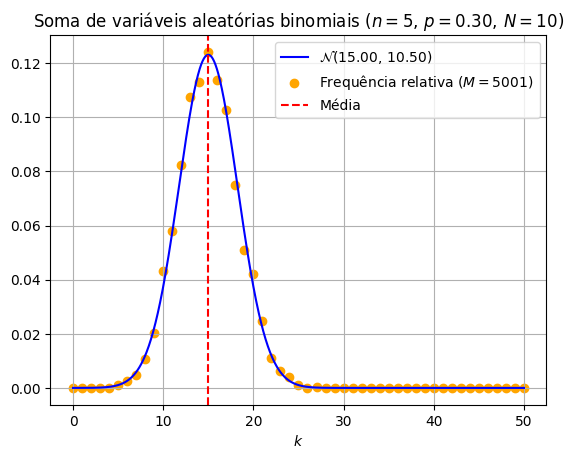

In [ ]:
def S(n,p,N): # Realiza a soma de N variáveis aleatórias binomiais
    soma = 0
    for k in range(0,N,1):
        soma += eventos.Bin(n,p)
    return soma

n = 5 # Número de repetições
p = 0.3 # Probabilidade de sucesso em uma repetição
N = 10 # Número de variáveis de Bernoulli a serem somadas

EX_bin = n*p
sigma_bin2 = n*p*(1-p)

k_array = np.arange(0,N*n+1,1)
M = 5001
frequencia_relativa = np.zeros(len(k_array))
for m in range(0,M,1):
    s = S(n,p,N)
    indice = np.where(k_array == s)[0]
    frequencia_relativa[indice] += 1/M

t_array = np.linspace(0, np.max(k_array), 1001)

plt.plot(t_array, eventos.prob_Gaussiana(t_array, N*EX_bin, N*sigma_bin2), color = 'blue', label = r'$\mathcal{N}(%.2f,\,%.2f)$' %(N*EX_bin, N*sigma_bin2))
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($M=%d$)' %M, color = 'orange')
plt.axvline(N*EX_bin, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Soma de variáveis aleatórias binomiais ($n = %d,\,p = %.2f,\,N = %d$)' %(n,p,N))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()

### Variáveis aleatórias geométricas ###

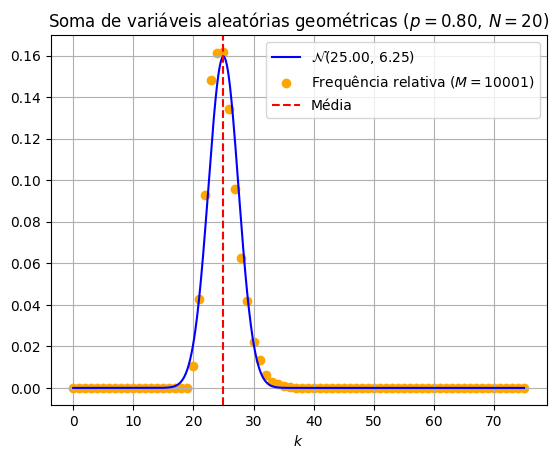

In [ ]:
def S(p,N):
    soma = 0
    for k in range(0,N,1):
        soma += eventos.Geom(p)
    return soma

p = 0.8
N = 20

if p == 0:
    k_max = 1
else:
    k_max = int(3*N*(1/p))

EX_geom = 1/p
sigma_geom2 =  (1-p)/p**2

k_array = np.arange(0,k_max+1,1)
M = 10001
frequencia_relativa = np.zeros(len(k_array))
for m in range(0,M,1):
    s = S(p,N)
    indice = np.where(k_array == s)[0]
    frequencia_relativa[indice] += 1/M

t_array = np.linspace(0, np.max(k_array), 1001)

plt.plot(t_array, eventos.prob_Gaussiana(t_array, N*EX_geom, N*sigma_geom2), color = 'blue', label = r'$\mathcal{N}(%.2f,\,%.2f)$' %(N*EX_geom, N*sigma_geom2))
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($M=%d$)' %M, color = 'orange')
plt.axvline(N*EX_geom, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Soma de variáveis aleatórias geométricas ($p = %.2f,\,N = %d$)' %(p,N))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()

### Variáveis aleatórias de Poisson ###

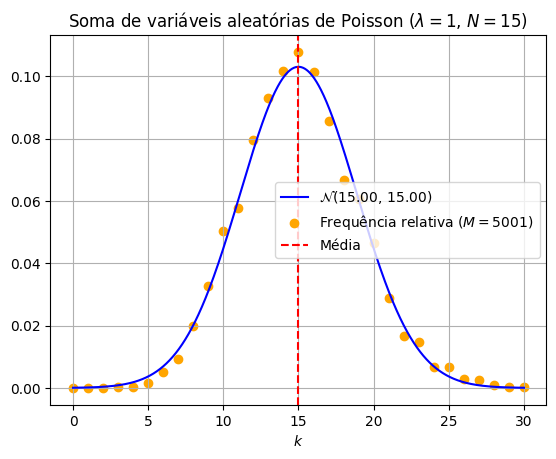

In [57]:
def S(lambda_,N):
    soma = 0
    for k in range(0,N,1):
        soma += eventos.Poisson(lambda_)
    return soma

lambda_ = 1
N = 15

if lambda_ == 0:
    k_max = 2
else:
    k_max = 2*N*lambda_

k_array = np.arange(0,k_max+1,1)
M = 5001
frequencia_relativa = np.zeros(len(k_array))
for m in range(0,M,1):
    s = S(lambda_,N)
    indice = np.where(k_array == s)[0]
    frequencia_relativa[indice] += 1/M

t_array = np.linspace(0, np.max(k_array), 1001)

plt.plot(t_array, eventos.prob_Gaussiana(t_array, N*lambda_, N*lambda_), color = 'blue', label = r'$\mathcal{N}(%.2f,\,%.2f)$' %(N*lambda_, N*lambda_))
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($M=%d$)' %M, color = 'orange')
plt.axvline(N*lambda_, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Soma de variáveis aleatórias de Poisson ($\lambda = %d,\,N = %d$)' %(lambda_,N))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()

### Variáveis aleatórias com distribuição de probabilidades qualquer ###

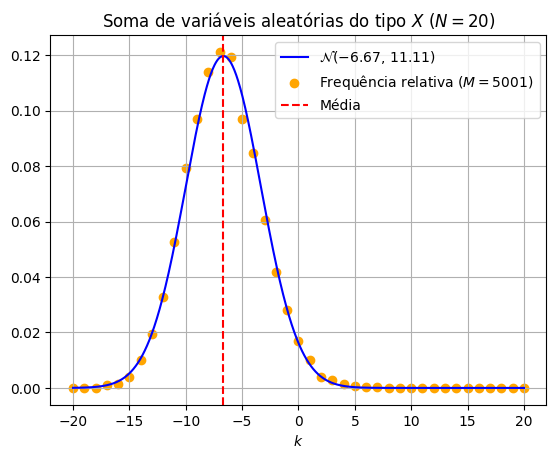

In [ ]:
'''
Coloque uma distribuição de probabilidade qualquer aqui.

Distribuição utilizada: X assume valores no conjunto {-1,0,1}, com P[X=-1] = 1/2, P[X=0] = 1/3 e P[X=1] = 1/6.
'''

I = np.array([-1,0,1])
p_array = np.array([1/2,1/3,1/6])

def X():
    return np.random.choice(I, p=p_array)

EX = 0
for k in range(0, len(I), 1): # Calcula a média
    xi = I[k]
    pi = p_array[k]
    EX += xi*pi

EX2 = 0
for k in range(0, len(I), 1): # Calcula o segundo momento
    xi2 = I[k]**2
    pi = p_array[k]
    EX2 += xi2*pi
sigma_X2 = EX2 - EX**2 # Calcula a variância

def S(N):
    soma = 0
    for k in range(0,N,1):
        soma += X()
    return soma

N = 20

k_array = np.arange(-N,N+1, 1)
M = 5001
frequencia_relativa = np.zeros(len(k_array))
for m in range(0,M,1):
    s = S(N)
    indice = np.where(k_array == s)[0]
    frequencia_relativa[indice] += 1/M

t_array = np.linspace(np.min(k_array), np.max(k_array), 1001)

plt.plot(t_array, eventos.prob_Gaussiana(t_array, N*EX, N*sigma_X2), color = 'blue', label = r'$\mathcal{N}(%.2f,\,%.2f)$' %(N*EX, N*sigma_X2))
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($M=%d$)' %M, color = 'orange')
plt.axvline(N*EX, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Soma de variáveis aleatórias do tipo $X$ ($N = %d$)' %(N))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()